# Importing Necessary Libraries

In [59]:
import pandas as pd 
import numpy as np
import math
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OrdinalEncoder,OneHotEncoder,LabelEncoder,StandardScaler
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score,mean_absolute_error
from sklearn.decomposition import PCA

# Loading the Dataset


In [47]:
data=pd.read_csv("C:/Users/phgtk/datasets/food.csv")
data.head(20)

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Ordered,Time_Order_picked,Weather,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken
0,0x4607,INDORES13DEL02,37,4.9,22.745049,75.892471,22.765049,75.912471,19-03-2022,11:30:00,11:45:00,Sunny,High,2,Snack,motorcycle,0,0,Urban,24
1,0xb379,BANGRES18DEL02,34,4.5,12.913041,77.683237,13.043041,77.813237,25-03-2022,19:45:00,19:50:00,Stormy,Jam,2,Snack,scooter,1,0,Metropolitian,33
2,0x5d6d,BANGRES19DEL01,23,4.4,12.914264,77.678400,12.924264,77.688400,19-03-2022,08:30:00,08:45:00,Sandstorms,Low,0,Drinks,motorcycle,1,0,Urban,26
3,0x7a6a,COIMBRES13DEL02,38,4.7,11.003669,76.976494,11.053669,77.026494,05-04-2022,18:00:00,18:10:00,Sunny,Medium,0,Buffet,motorcycle,1,0,Metropolitian,21
4,0x70a2,CHENRES12DEL01,32,4.6,12.972793,80.249982,13.012793,80.289982,26-03-2022,13:30:00,13:45:00,Cloudy,High,1,Snack,scooter,1,0,Metropolitian,30
5,0x9bb4,HYDRES09DEL03,22,4.8,17.431668,78.408321,17.461668,78.438321,11-03-2022,21:20:00,21:30:00,Cloudy,Jam,0,Buffet,motorcycle,1,0,Urban,26
6,0x95b4,RANCHIRES15DEL01,33,4.7,23.369746,85.339820,23.479746,85.449820,04-03-2022,19:15:00,19:30:00,Fog,Jam,1,Meal,scooter,1,0,Metropolitian,40
7,0x9eb2,MYSRES15DEL02,35,4.6,12.352058,76.606650,12.482058,76.736650,14-03-2022,17:25:00,17:30:00,Cloudy,Medium,2,Meal,motorcycle,1,0,Metropolitian,32
8,0x1102,HYDRES05DEL02,22,4.8,17.433809,78.386744,17.563809,78.516744,20-03-2022,20:55:00,21:05:00,Stormy,Jam,0,Buffet,motorcycle,1,0,Metropolitian,34
9,0xcdcd,DEHRES17DEL01,36,4.2,30.327968,78.046106,30.397968,78.116106,12-02-2022,21:55:00,22:10:00,Fog,Jam,2,Snack,motorcycle,3,0,Metropolitian,46


# Data Preprocessing
## Checking for Missing Values

In [48]:
data.isnull().sum()

ID                             0
Delivery_person_ID             0
Delivery_person_Age            0
Delivery_person_Ratings        0
Restaurant_latitude            0
Restaurant_longitude           0
Delivery_location_latitude     0
Delivery_location_longitude    0
Order_Date                     0
Time_Ordered                   0
Time_Order_picked              0
Weather                        0
Road_traffic_density           0
Vehicle_condition              0
Type_of_order                  0
Type_of_vehicle                0
multiple_deliveries            0
Festival                       0
City                           0
Time_taken                     0
dtype: int64

# Encoding for Categorical Data 

## Ordinal Encoding for Categorical Data

In [49]:
ordinal_mapping = {
    'Road_traffic_density': ['Low', 'Medium', 'High', 'Jam'],
    'Type_of_order': ['Drinks', 'Snack', 'Meal', 'Buffet'],
    'Type_of_vehicle': ['motorcycle', 'scooter', 'electric_scooter'],
    'City': ['Semi-Urban', 'Urban', 'Metropolitian'],'Weather':['Sunny','Windy','Stormy','Sandstorms','Cloudy','Fog']
}

for col, categories in ordinal_mapping.items():
    data[col] = data[col].str.strip()
    encoder = OrdinalEncoder(categories=[categories])
    data[col] = encoder.fit_transform(data[[col]])




In [50]:
data['Order_Date'] = pd.to_datetime(data['Order_Date'], dayfirst=True)
data['Order_day'] = data['Order_Date'].dt.day
data['Order_month'] = data['Order_Date'].dt.month
data['Order_year'] = data['Order_Date'].dt.year
data['Order_day_of_week'] = data['Order_Date'].dt.dayofweek
data['Hour'] = pd.to_numeric(data['Time_Ordered'].astype(str).str.split(':').str[0], errors='coerce')

In [51]:
cols_to_drop = ['Order_Date']
data = data.drop(columns=cols_to_drop, errors='ignore')

# Transformed Data 

In [52]:
data

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Time_Ordered,Time_Order_picked,...,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken,Order_day,Order_month,Order_year,Order_day_of_week,Hour
0,0x4607,INDORES13DEL02,37,4.9,22.745049,75.892471,22.765049,75.912471,11:30:00,11:45:00,...,0.0,0,0,1.0,24,19,3,2022,5,11
1,0xb379,BANGRES18DEL02,34,4.5,12.913041,77.683237,13.043041,77.813237,19:45:00,19:50:00,...,1.0,1,0,2.0,33,25,3,2022,4,19
2,0x5d6d,BANGRES19DEL01,23,4.4,12.914264,77.678400,12.924264,77.688400,08:30:00,08:45:00,...,0.0,1,0,1.0,26,19,3,2022,5,8
3,0x7a6a,COIMBRES13DEL02,38,4.7,11.003669,76.976494,11.053669,77.026494,18:00:00,18:10:00,...,0.0,1,0,2.0,21,5,4,2022,1,18
4,0x70a2,CHENRES12DEL01,32,4.6,12.972793,80.249982,13.012793,80.289982,13:30:00,13:45:00,...,1.0,1,0,2.0,30,26,3,2022,5,13
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
38059,0x1178,RANCHIRES16DEL01,35,4.2,23.371292,85.327872,23.481292,85.437872,21:45:00,21:55:00,...,0.0,1,0,2.0,33,8,3,2022,1,21
38060,0x7c09,JAPRES04DEL01,30,4.8,26.902328,75.794257,26.912328,75.804257,11:35:00,11:45:00,...,0.0,0,0,2.0,32,24,3,2022,3,11
38061,0x4f8d,CHENRES08DEL03,30,4.9,13.022394,80.242439,13.052394,80.272439,23:50:00,00:05:00,...,1.0,0,0,2.0,16,11,3,2022,4,23
38062,0x5eee,COIMBRES11DEL01,20,4.7,11.001753,76.986241,11.041753,77.026241,13:35:00,13:40:00,...,0.0,1,0,2.0,26,7,3,2022,0,13


# Using Regression to Predict Delivery Times

In [53]:
X = data.drop(['ID', 'Delivery_person_ID','Time_Order_picked','Time_Ordered', 'Time_taken'], axis=1)
y = data['Time_taken']

## Choosing our Best Model 

In [18]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

models = {"Linear Regression": LinearRegression(),"SVR": SVR(),"Decision Tree": DecisionTreeRegressor(random_state=42),"Random Forest": RandomForestRegressor(random_state=42)}


print("Model Performance on Test Set")
results = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    results[name] = r2 
    
    print(f"\n{name}:")
    print(f"  RMSE: {rmse:.4f}")
    print(f"  R2 Score: {r2:.4f}")



Model Performance on Test Set

Linear Regression:
  RMSE: 6.0934
  R2 Score: 0.5754

SVR:
  RMSE: 5.6311
  R2 Score: 0.6374

Decision Tree:
  RMSE: 6.0368
  R2 Score: 0.5833

Random Forest:
  RMSE: 4.3954
  R2 Score: 0.7791


## Training our Best Model and Visualising the Results

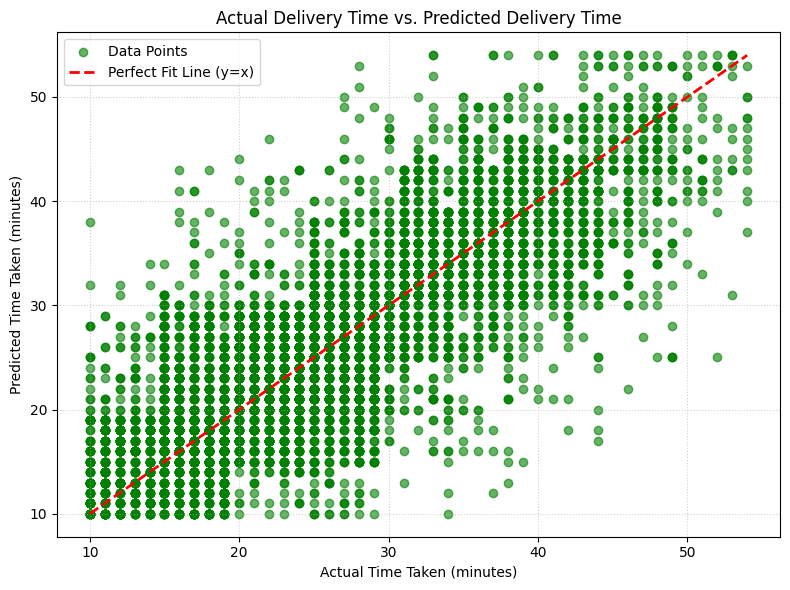

In [54]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
model =  DecisionTreeRegressor(random_state=42)
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

plt.figure(figsize=(8, 6))


plt.scatter(y_test, y_pred, alpha=0.6, color='green', label='Data Points')


min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], 
         linestyle='--', color='red', linewidth=2, label='Perfect Fit Line (y=x)')

plt.title('Actual Delivery Time vs. Predicted Delivery Time')
plt.xlabel('Actual Time Taken (minutes)')
plt.ylabel('Predicted Time Taken (minutes)')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

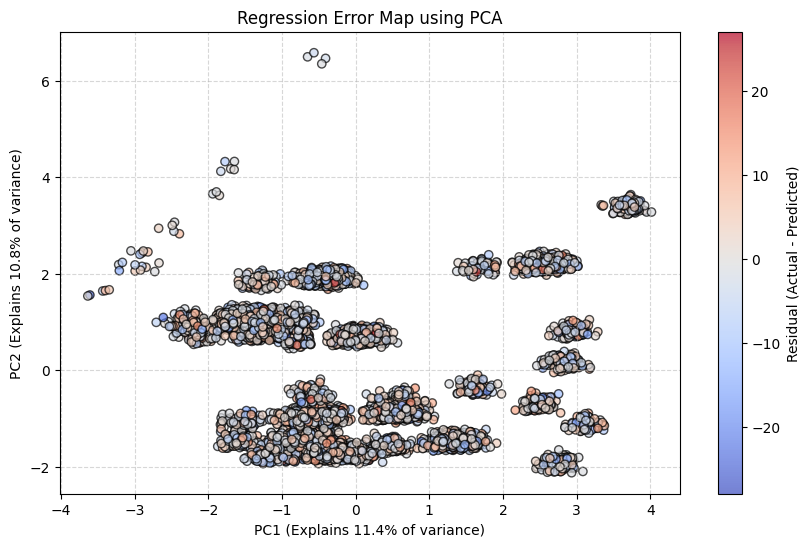

In [55]:
residuals = y_test-y_pred
pca= PCA(n_components = 2)
X_pca=pca.fit_transform(X_test_scaled)
plt.figure(figsize=(10, 6))

scatter = plt.scatter(X_pca[:, 0],X_pca[:, 1],c=residuals,cmap='coolwarm', edgecolor='k',alpha=0.7)


plt.colorbar(scatter, label='Residual (Actual - Predicted)')
plt.title('Regression Error Map using PCA')
plt.xlabel(f'PC1 (Explains {pca.explained_variance_ratio_[0]:.1%} of variance)')
plt.ylabel(f'PC2 (Explains {pca.explained_variance_ratio_[1]:.1%} of variance)')
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

# Deciding when to apply Surge Fees

### Clustering the Data based on Geographical Features

Zone Distribution
Zone_ID
0     3532
5     3291
1     3137
12    2908
4     2905
2     2880
11    2878
14    2839
6     2835
17    2715
Name: count, dtype: int64


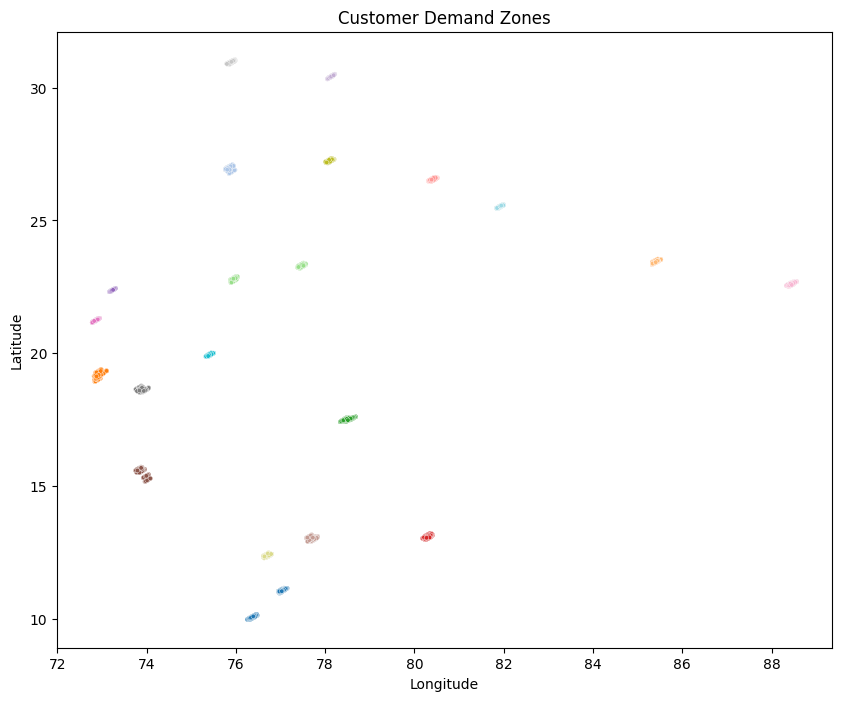

In [56]:
coords = data[['Delivery_location_latitude', 'Delivery_location_longitude']].copy()
valid_coords = coords[(coords['Delivery_location_latitude'] != 0) & (coords['Delivery_location_longitude'] != 0)]
kmeans = KMeans(n_clusters=20, random_state=42, n_init=10)
kmeans.fit(valid_coords)
data.loc[valid_coords.index, 'Zone_ID'] = kmeans.labels_
data['Zone_ID'] = data['Zone_ID'].fillna(-1).astype(int)
print("Zone Distribution")
print(data['Zone_ID'].value_counts().head(10))

#Visualizing the Clusters
plt.figure(figsize=(10, 8))
valid_data = data[data['Zone_ID'] != -1]
sns.scatterplot(x='Delivery_location_longitude', y='Delivery_location_latitude', hue='Zone_ID', data=valid_data, palette='tab20', s=10, legend=False)
plt.title('Customer Demand Zones')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

### Creating Historical Features for knowing Demand Last Hour and Demand Last Day during Same Hour 

In [57]:
df_agg = data[data['Zone_ID'] != -1].groupby(['Zone_ID', 'Order_year','Order_day_of_week', 'Order_month', 'Order_day', 'Hour']).agg(Actual_Demand=('ID', 'count'), Avg_Delivery_Time=('Time_taken', 'mean'),Avg_Rating=('Delivery_person_Ratings', 'mean')  ).reset_index()
df_agg = df_agg.sort_values(by=['Zone_ID', 'Order_year', 'Order_month', 'Order_day', 'Hour'])
df_agg['Demand_Last_Hour'] = df_agg.groupby('Zone_ID')['Actual_Demand'].shift(1)
df_agg['Demand_Yesterday_Same_Hour'] = df_agg.groupby('Zone_ID')['Actual_Demand'].shift(24)
df_agg = df_agg.dropna()
print("Aggregated Data Ready for Forecasting")
print(df_agg.head())
print(f"\nTotal training samples: {len(df_agg)}")

Aggregated Data Ready for Forecasting
     Zone_ID  Order_year  Order_day_of_week  Order_month  Order_day  Hour  \
392        0        2022                  5            2         12    23   
457        0        2022                  6            2         13     8   
458        0        2022                  6            2         13     9   
459        0        2022                  6            2         13    10   
460        0        2022                  6            2         13    11   

     Actual_Demand  Avg_Delivery_Time  Avg_Rating  Demand_Last_Hour  \
392             11          25.181818    4.645455               9.0   
457              3          15.666667    4.666667              11.0   
458              9          19.444444    4.733333               3.0   
459              7          23.857143    4.571429               9.0   
460              6          34.166667    4.516667               7.0   

     Demand_Yesterday_Same_Hour  
392                         1.0  
457 

### Predicting Demand for Next hour using Random Forests 

In [60]:
df_agg['Traffic_Last_Hour'] = df_agg.groupby('Zone_ID')['Avg_Delivery_Time'].shift(1)
features = ['Zone_ID', 'Hour', 'Demand_Last_Hour', 'Demand_Yesterday_Same_Hour', 'Traffic_Last_Hour','Order_day_of_week']
X = df_agg[features]
y = df_agg['Actual_Demand']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_pred = rf_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print("Demand Forecasting Model Results")
print(f"Mean Absolute Error: {mae:.2f} orders") 
print(f"R2 Score: {r2:.4f}")

results_df = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
print("\nPrediction Snapshot")
print(results_df.head().round(1))

Demand Forecasting Model Results
Mean Absolute Error: 2.00 orders
R2 Score: 0.4838

Prediction Snapshot
      Actual  Predicted
3910       7        6.4
1348       2        6.3
93         1        2.7
166        1        1.4
454       10        8.5


### Deciding the Classification Threshold

In [62]:
zone_capacity = df_agg.groupby('Zone_ID')['Actual_Demand'].quantile(0.75).to_dict()

def get_surge_multiplier(predicted_demand, zone_id):
    threshold = zone_capacity.get(zone_id, 100) 
    if predicted_demand > threshold:
        if predicted_demand > (threshold * 1.2):
            return 1.5
        else:
            return 1.2
    else:
        return 1.0


simulation = X_test.copy()
simulation['Actual_Demand'] = y_test
simulation['Predicted_Demand'] = y_pred  


simulation['Surge_Multiplier'] = simulation.apply(
    lambda row: get_surge_multiplier(row['Predicted_Demand'], row['Zone_ID']), axis=1
)


base_fee = 10.00

# Calculate Revenue without Surge vs. Revenue with Surge
simulation['Revenue_Base'] = simulation['Actual_Demand'] * base_fee
simulation['Revenue_Dynamic'] = simulation['Actual_Demand'] * (base_fee * simulation['Surge_Multiplier'])

# Review Results
total_base_rev = simulation['Revenue_Base'].sum()
total_dynamic_rev = simulation['Revenue_Dynamic'].sum()
extra_revenue = total_dynamic_rev - total_base_rev

print("Surge Pricing Simulation")
print(f"Total Base Revenue:     Rs.{total_base_rev:,.2f}")
print(f"Total Dynamic Revenue:  Rs.{total_dynamic_rev:,.2f}")
print(f"Extra Revenue Generated: Rs.{extra_revenue:,.2f} (+{(extra_revenue/total_base_rev)*100:.1f}%)")

print("\n Look at Changes in Price Decisions")
# Show a few rows where Surge was triggered (Multiplier > 1.0)
print(simulation[simulation['Surge_Multiplier'] > 1.0][
    ['Zone_ID', 'Hour', 'Predicted_Demand', 'Surge_Multiplier']
].head())

Surge Pricing Simulation
Total Base Revenue:     Rs.69,020.00
Total Dynamic Revenue:  Rs.76,036.00
Extra Revenue Generated: Rs.7,016.00 (+10.2%)

 Look at Changes in Price Decisions
      Zone_ID  Hour  Predicted_Demand  Surge_Multiplier
819         1    23             12.36               1.5
3981       11    22             10.80               1.5
4316       12    23              9.78               1.2
3023        6    18             10.17               1.2
494         0    22              9.17               1.2


# Clustering Drivers Based on Performance to get insights,

--- Cluster Profiles (Who are they?) ---
         Delivery_person_Age  Delivery_person_Ratings  Time_taken  \
Cluster                                                             
0                  29.366318                 4.698328   25.125115   
1                  29.605410                 4.630906   26.547073   
2                  29.974734                 4.568992   28.332357   

         Total_Deliveries  
Cluster                    
0               13.576642  
1               48.908948  
2               12.439216  


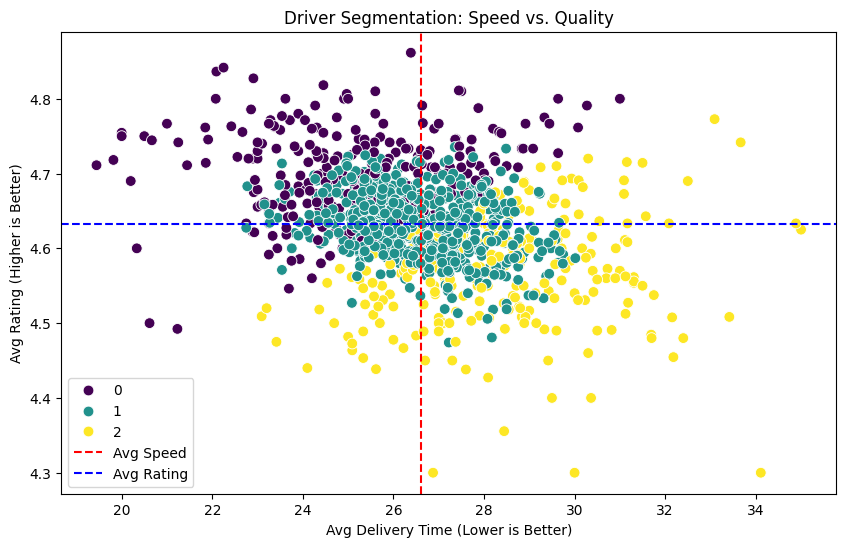


--- HIRING INSIGHTS (Based on 'Best' Cluster 0) ---
The 'Star Drivers' make up 274 people.
Their Common Traits:
- Average Age: 29.4 years old
- Consistency: They have completed avg 14 deliveries


In [65]:
driver_profiles = data.groupby('Delivery_person_ID').agg({
    'Delivery_person_Age': 'mean',          
    'Delivery_person_Ratings': 'mean',      
    'Time_taken': 'mean',                   
    'ID': 'count'                           
}).rename(columns={'ID': 'Total_Deliveries'})


driver_profiles = driver_profiles[driver_profiles['Total_Deliveries'] > 5]


scaler = StandardScaler()
features_to_cluster = ['Delivery_person_Ratings', 'Time_taken', 'Total_Deliveries']
scaled_features = scaler.fit_transform(driver_profiles[features_to_cluster])


kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
driver_profiles['Cluster'] = kmeans.fit_predict(scaled_features)


cluster_analysis = driver_profiles.groupby('Cluster').mean().sort_values(by='Delivery_person_Ratings', ascending=False)

print("--- Cluster Profiles (Who are they?) ---")
print(cluster_analysis)


plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=driver_profiles, 
    x='Time_taken', 
    y='Delivery_person_Ratings', 
    hue='Cluster', 
    palette='viridis',
    s=60
)
plt.title('Driver Segmentation: Speed vs. Quality')
plt.xlabel('Avg Delivery Time (Lower is Better)')
plt.ylabel('Avg Rating (Higher is Better)')
plt.axvline(x=driver_profiles['Time_taken'].mean(), color='red', linestyle='--', label='Avg Speed')
plt.axhline(y=driver_profiles['Delivery_person_Ratings'].mean(), color='blue', linestyle='--', label='Avg Rating')
plt.legend()
plt.show()


best_cluster_id = cluster_analysis['Delivery_person_Ratings'].idxmax()
best_drivers = driver_profiles[driver_profiles['Cluster'] == best_cluster_id]

print(f"\n--- HIRING INSIGHTS (Based on 'Best' Cluster {best_cluster_id}) ---")
print(f"The 'Star Drivers' make up {len(best_drivers)} people.")
print(f"Their Common Traits:")
print(f"- Average Age: {best_drivers['Delivery_person_Age'].mean():.1f} years old")
print(f"- Consistency: They have completed avg {best_drivers['Total_Deliveries'].mean():.0f} deliveries")